# Credit Risk Modeling on Lending Club — LR vs Random Forest vs XGBoost

Benchmarks three classical / boosted classifiers on the
[Lending Club accepted loans dataset](https://www.kaggle.com/datasets/wordsforthewise/lending-club)
for predicting whether a loan goes bad.

For each algorithm we report performance with **default** and **Optuna-tuned**
hyperparameters.

| Model | Library | GPU |
| :--- | :--- | :--- |
| Logistic Regression | scikit-learn | No |
| Random Forest | scikit-learn | No |
| XGBoost | xgboost | Yes (tuning + final) |

Preprocessing, evaluation, and tracking logic live in the shared
[`src/`](../src) module so this notebook, the Home Credit baseline notebook,
and the FT-Transformer notebooks all run on **identical splits and identical
features**, and all write artifacts in a uniform layout.

**What gets saved.** After every model trains, `save_run_artifacts` writes:
- `{model}_perf.csv` — train/valid/test metrics
- `{model}_best_params.json` — tuned hyperparameters
- `{model}_study.csv` — full Optuna trial history
- `{model}_predictions_test.npy` — test-set scores (for cross-model comparisons later)
- appends a test-set row to `results/summary_test_metrics_lending_club.csv`

Plus per-dataset:
- `timings.csv` — wall-clock for default train, tuned train, tuning loop, inference
- `environment.json` — Python/library versions, GPU info, seed

> **Scope.** FT-Transformer experiments are in a separate notebook.

## 1. Setup

In [ ]:
# Install dependencies (uncomment on a fresh environment)
!pip install -q optuna xgboost shap scikit-learn pandas numpy joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.0 MB/s eta 0:00:00


In [ ]:
import os
import sys
import warnings

import numpy as np
import pandas as pd

# Make the shared src/ module importable when this notebook lives under notebooks/
sys.path.insert(0, os.path.abspath(".."))

from src.datasets import load_lending_club, preprocess_lending_club
from src.preprocessing import preprocess_data_pipeline, seed_everything
from src.evaluation import report_performance
from src.interpretation import (
    get_shap_importance_xgb,
    get_shap_importance_rf,
    plot_shap_summary,
)
from src.tracking import (
    ExperimentLogger,
    time_block,
    capture_environment,
    save_run_artifacts,
    measure_inference_time,
    load_summary,
    load_timings,
)

import optuna
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import joblib

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.options.display.max_rows = 200
pd.options.display.max_columns = 200

RANDOM_SEED = 42
seed_everything(RANDOM_SEED)

### 1.1 Paths and tracking

The path cell auto-routes through `DRIVE_ROOT` if you uncomment the Colab
Drive mount cell below. `ExperimentLogger` then sets up two directories:

* `artifacts/lending_club/` — per-run outputs (gitignored)
* `results/` — curated summary tables (committed to git)

In [ ]:
# --- Optional: Google Colab Drive mount ---
# Uncomment the three lines below if you're running on Colab and want to read
# data from / write artifacts to your Drive. Skip on local, server, or Kaggle
# runs. The next cell auto-routes through DRIVE_ROOT when defined.

from google.colab import drive
drive.mount("/content/drive")
DRIVE_ROOT = "/content/drive/MyDrive/credit_risk_modeling"


Mounted at /content/drive


In [ ]:
# When running locally, repo root is one directory up (notebook is in notebooks/).
# When running on Colab with the cell above uncommented, DRIVE_ROOT takes precedence.
_BASE = globals().get("DRIVE_ROOT", "..")
DATA_PATH      = f"{_BASE}/data/accepted_2007_to_2018Q4.csv"
ARTIFACTS_DIR  = f"{_BASE}/artifacts/lending_club"
RESULTS_DIR    = f"{_BASE}/results"

logger = ExperimentLogger(
    dataset="lending_club",
    artifacts_dir=ARTIFACTS_DIR,
    results_dir=RESULTS_DIR,
)
print(f"DATA_PATH      = {DATA_PATH}")
print(f"ARTIFACTS_DIR  = {ARTIFACTS_DIR}")
print(f"RESULTS_DIR    = {RESULTS_DIR}")

# Capture environment once per session
capture_environment(logger, seed=RANDOM_SEED);

DATA_PATH      = /content/drive/MyDrive/credit_risk_modeling/data/accepted_2007_to_2018Q4.csv
ARTIFACTS_DIR  = /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club
RESULTS_DIR    = /content/drive/MyDrive/credit_risk_modeling/results
  [env] captured -> /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/environment.json


## 2. Data Loading and Cleaning

`load_lending_club` reads only the 63 application-time columns, and
`preprocess_lending_club` defines the binary target, fixes percent-string
columns, drops free-text identifiers, and collapses rare ZIPs into 'Others'.

In [ ]:
df = load_lending_club(DATA_PATH)
df = preprocess_lending_club(df)

/content/src/datasets.py:62: DtypeWarning: Columns (0,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, usecols=LENDING_CLUB_COLS)


Raw shape: (2260701, 63)
Shape after cleaning: (1373154, 61)
Target rate: 0.2112


## 3. Preprocessing Pipeline

`preprocess_data_pipeline` performs the stratified 64/16/20 split, drops
high-missingness columns, drops highly-correlated numerics (keeping the one
more correlated with the target), median-imputes, label-encodes categoricals,
and standard-scales. **Everything is fit on the training split only.**

In [ ]:
data = preprocess_data_pipeline(
    df, target="target_binary", corr_threshold=0.9, missing_threshold=0.9
)

X_train, X_valid, X_test = data.as_concatenated()
y_train, y_valid, y_test = data.y_train, data.y_valid, data.y_test

print("\nDataset Split Summary")
print("-" * 40)
print(f"Train : X = {X_train.shape},  y = {y_train.shape}")
print(f"Valid : X = {X_valid.shape},  y = {y_valid.shape}")
print(f"Test  : X = {X_test.shape},   y = {y_test.shape}")
print()
print(f"Numeric features    : {len(data.num_cols)}")
print(f"Categorical features: {len(data.cat_cols)}")

Step 1: Stratified split (64/16/20)
  Train=878,818 | Valid=219,705 | Test=274,631
Step 2: Missing-value column filter
  Threshold: 90% | Dropped 15 columns
Step 3: Correlation drop (numeric)
  Numeric features before: 35 | Dropped: 3
Step 4: Median imputation (numeric)
Step 5: Label encoding (categorical)
Step 6: Standard scaling (numeric)

Final feature counts: numeric=32 | categorical=10 | total=42
Categorical cardinalities: [2, 11, 6, 3, 14, 571, 51, 2, 2, 2]

Dataset Split Summary
----------------------------------------
Train : X = (878818, 42),  y = (878818,)
Valid : X = (219705, 42),  y = (219705,)
Test  : X = (274631, 42),   y = (274631,)

Numeric features    : 32
Categorical features: 10


## 4. Logistic Regression

### 4.1 Default hyperparameters

In [ ]:
logreg_default = LogisticRegression()

with time_block("train", logger, model_name="lr_default"):
    logreg_default.fit(X_train, y_train)

perf_lr_default = report_performance(
    logreg_default, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    logreg_default, X_test, n_repeats=5,
    logger=logger, model_name="lr_default",
);

save_run_artifacts(
    logger,
    model_name="lr_default",
    perf_df=perf_lr_default,
    test_predictions=logreg_default.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)
perf_lr_default

  [timer] starting: lr_default/train
  [timer] lr_default/train: 20.20s (0.34 min)
  [inference] lr_default: median=2.06ms std=0.08ms (over 5 runs, 10000 samples)
  [save] lr_default: wrote 2 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/lr_default_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/lr_default_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,878818,185642,0.2112,0.688564,0.377129,0.272697,0.364994,0.445848,0.211062
Value,Validation,219705,46411,0.2112,0.688107,0.376214,0.269692,0.365802,0.448273,0.212213
Value,Test,274631,58013,0.2112,0.688899,0.377799,0.276119,0.364269,0.441196,0.208867


### 4.2 Hyperparameter tuning with Optuna

In [ ]:
def tune_lr_objective(trial):
    C = trial.suggest_float("C", 1e-5, 100, log=True)
    penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
    use_balanced = trial.suggest_categorical("use_balanced", [True, False])
    class_weight = "balanced" if use_balanced else None

    model = LogisticRegression(
        C=C, penalty=penalty, solver="liblinear",
        class_weight=class_weight, random_state=RANDOM_SEED, max_iter=1000,
    )
    model.fit(X_train, y_train)
    val_preds = model.predict_proba(X_valid)[:, 1]
    return roc_auc_score(y_valid, val_preds)


N_TRIALS_LR = 20

study_lr = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="LR_LendingClub_Tuning",
)

with time_block("tuning_loop", logger, model_name="lr_tuned"):
    study_lr.optimize(tune_lr_objective, n_trials=N_TRIALS_LR, show_progress_bar=True)

print(f"\nBest validation AUC: {study_lr.best_value:.5f}")
print("Best params:")
for k, v in study_lr.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-13 09:47:01,682] A new study created in memory with name: LR_LendingClub_Tuning


  [timer] starting: lr_tuned/tuning_loop


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-13 09:47:31,922] Trial 0 finished with value: 0.7092467393899398 and parameters: {'C': 0.004185822729546971, 'penalty': 'l1', 'use_balanced': True}. Best is trial 0 with value: 0.7092467393899398.
[I 2026-05-13 09:47:58,109] Trial 1 finished with value: 0.7000766662355611 and parameters: {'C': 0.0001235838277230692, 'penalty': 'l2', 'use_balanced': False}. Best is trial 0 with value: 0.7092467393899398.
[I 2026-05-13 09:48:01,060] Trial 2 finished with value: 0.6807991575780641 and parameters: {'C': 1.3934502251337587e-05, 'penalty': 'l1', 'use_balanced': True}. Best is trial 0 with value: 0.7092467393899398.
[I 2026-05-13 09:48:18,141] Trial 3 finished with value: 0.7089506385983753 and parameters: {'C': 0.00019223460470643635, 'penalty': 'l2', 'use_balanced': True}. Best is trial 0 with value: 0.7092467393899398.
[I 2026-05-13 09:48:45,904] Trial 4 finished with value: 0.7088128473828762 and parameters: {'C': 0.19185373703841915, 'penalty': 'l2', 'use_balanced': False}. Be

### 4.3 Final logistic regression with tuned hyperparameters

In [ ]:
best_params_lr = study_lr.best_params

logreg = LogisticRegression(
    C=best_params_lr["C"],
    penalty=best_params_lr["penalty"],
    class_weight="balanced" if best_params_lr.get("use_balanced") else None,
    solver="liblinear",
    random_state=RANDOM_SEED,
    max_iter=1000,
)

with time_block("train", logger, model_name="lr_tuned"):
    logreg.fit(X_train, y_train)

perf_lr_tuned = report_performance(
    logreg, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    logreg, X_test, n_repeats=5,
    logger=logger, model_name="lr_tuned",
);

save_run_artifacts(
    logger,
    model_name="lr_tuned",
    perf_df=perf_lr_tuned,
    best_params=best_params_lr,
    study=study_lr,
    test_predictions=logreg.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)

joblib.dump(logreg, logger.artifact_path("logistic_regression.pkl"))
perf_lr_tuned

  [timer] starting: lr_tuned/train
  [timer] lr_tuned/train: 27.93s (0.47 min)
  [inference] lr_tuned: median=1.91ms std=0.10ms (over 5 runs, 10000 samples)
  [save] lr_tuned: wrote 4 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/lr_tuned_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/lr_tuned_best_params.json
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/lr_tuned_study.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/lr_tuned_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,878818,185642,0.2112,0.710047,0.420094,0.305105,0.387410,0.473783,0.224287
Value,Validation,219705,46411,0.2112,0.709336,0.418671,0.304854,0.387186,0.474671,0.224710
Value,Test,274631,58013,0.2112,0.709734,0.419467,0.305499,0.387741,0.472546,0.223708


## 5. Random Forest

### 5.1 Default hyperparameters

In [ ]:
rf_default = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1)

with time_block("train", logger, model_name="rf_default"):
    rf_default.fit(X_train, y_train)

perf_rf_default = report_performance(
    rf_default, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    rf_default, X_test, n_repeats=5,
    logger=logger, model_name="rf_default",
);

save_run_artifacts(
    logger,
    model_name="rf_default",
    perf_df=perf_rf_default,
    test_predictions=rf_default.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)
perf_rf_default

  [timer] starting: rf_default/train
  [timer] rf_default/train: 445.07s (7.42 min)
  [inference] rf_default: median=438.94ms std=18.80ms (over 5 runs, 10000 samples)
  [save] rf_default: wrote 2 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/rf_default_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/rf_default_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,878818,185642,0.2112,1.000000,1.000000,1.000000,1.000000,1.000000,0.498847
Value,Validation,219705,46411,0.2112,0.711306,0.422612,0.306804,0.392517,0.478121,0.246019
Value,Test,274631,58013,0.2112,0.712841,0.425682,0.308405,0.394750,0.481775,0.246290


### 5.2 Hyperparameter tuning with Optuna

In [ ]:
def tune_rf_objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000),
        "max_samples": trial.suggest_float("max_samples", 0.6, 0.9),
        "max_depth": trial.suggest_int("max_depth", 2, 5),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 100),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 15, 50),
        "max_features": trial.suggest_float("max_features", 0.6, 0.9),
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy"]),
    }
    model = RandomForestClassifier(
        **params, class_weight="balanced_subsample",
        n_jobs=-1, random_state=RANDOM_SEED,
    )
    model.fit(X_train, y_train)
    val_pred = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, val_pred)
    print(f"Trial {trial.number} -> AUC: {auc:.5f}")
    return auc


N_TRIALS_RF = 10

study_rf = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="RF_LendingClub_Tuning",
)

with time_block("tuning_loop", logger, model_name="rf_tuned"):
    study_rf.optimize(tune_rf_objective, n_trials=N_TRIALS_RF, show_progress_bar=True)

print(f"\nBest validation AUC: {study_rf.best_value:.5f}")
print(f"Best params: {study_rf.best_params}")

[I 2026-05-13 10:03:47,352] A new study created in memory with name: RF_LendingClub_Tuning


  [timer] starting: rf_tuned/tuning_loop


  0%|          | 0/10 [00:00<?, ?it/s]

Trial 0 -> AUC: 0.69876
[I 2026-05-13 10:52:32,142] Trial 0 finished with value: 0.698762731966066 and parameters: {'n_estimators': 937, 'max_samples': 0.8852142919229748, 'max_depth': 4, 'min_samples_split': 64, 'min_samples_leaf': 20, 'max_features': 0.6467983561008608, 'criterion': 'entropy'}. Best is trial 0 with value: 0.698762731966066.
Trial 1 -> AUC: 0.69261
[I 2026-05-13 11:25:29,724] Trial 1 finished with value: 0.6926051682798539 and parameters: {'n_estimators': 1322, 'max_samples': 0.8124217733388137, 'max_depth': 2, 'min_samples_split': 98, 'min_samples_leaf': 44, 'max_features': 0.6637017332034828, 'criterion': 'entropy'}. Best is trial 0 with value: 0.698762731966066.
Trial 2 -> AUC: 0.69532
[I 2026-05-13 11:52:30,640] Trial 2 finished with value: 0.6953181345384452 and parameters: {'n_estimators': 817, 'max_samples': 0.7574269294896714, 'max_depth': 3, 'min_samples_split': 36, 'min_samples_leaf': 37, 'max_features': 0.6418481581956126, 'criterion': 'entropy'}. Best is t

### 5.3 Final random forest with tuned hyperparameters

In [ ]:
best_params_rf = study_rf.best_params

rf = RandomForestClassifier(
    **best_params_rf,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

with time_block("train", logger, model_name="rf_tuned"):
    rf.fit(X_train, y_train)

perf_rf_tuned = report_performance(
    rf, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    rf, X_test, n_repeats=5,
    logger=logger, model_name="rf_tuned",
);

save_run_artifacts(
    logger,
    model_name="rf_tuned",
    perf_df=perf_rf_tuned,
    best_params=best_params_rf,
    study=study_rf,
    test_predictions=rf.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)

joblib.dump(rf, logger.artifact_path("random_forest.pkl"))
perf_rf_tuned

  [timer] starting: rf_tuned/train
  [timer] rf_tuned/train: 1360.41s (22.67 min)
  [inference] rf_tuned: median=193.53ms std=2.02ms (over 5 runs, 10000 samples)
  [save] rf_tuned: wrote 4 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/rf_tuned_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/rf_tuned_best_params.json
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/rf_tuned_study.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/rf_tuned_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,878818,185642,0.2112,0.705606,0.411212,0.298691,0.383533,0.466034,0.220618
Value,Validation,219705,46411,0.2112,0.703545,0.407090,0.295009,0.381369,0.466979,0.221068
Value,Test,274631,58013,0.2112,0.704728,0.409456,0.297194,0.382981,0.465737,0.220485


## 6. XGBoost (GPU)

XGBoost uses GPU acceleration via `device="cuda"` for both tuning and the
final fit. Set `device="cpu"` if you don't have a CUDA GPU available.

### 6.1 Default hyperparameters

In [ ]:
EARLY_STOPPING_ROUNDS = 50

xgb_default_config = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
}

model_xgb_default = xgb.XGBClassifier(**xgb_default_config)

with time_block("train", logger, model_name="xgb_default"):
    model_xgb_default.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        verbose=100,
    )

perf_xgb_default = report_performance(
    model_xgb_default, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    model_xgb_default, X_test, n_repeats=5,
    logger=logger, model_name="xgb_default",
);

save_run_artifacts(
    logger,
    model_name="xgb_default",
    perf_df=perf_xgb_default,
    test_predictions=model_xgb_default.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)
perf_xgb_default

  [timer] starting: xgb_default/train
[0]	validation_0-auc:0.70335	validation_1-auc:0.70117
[99]	validation_0-auc:0.75371	validation_1-auc:0.72931
  [timer] xgb_default/train: 6.29s (0.10 min)
  [inference] xgb_default: median=10.94ms std=3.42ms (over 5 runs, 10000 samples)
  [save] xgb_default: wrote 2 artifacts
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/xgb_default_perf.csv
         - /content/drive/MyDrive/credit_risk_modeling/artifacts/lending_club/xgb_default_predictions_test.npy


,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,878818,185642,0.2112,0.753264,0.506528,0.369839,0.460080,0.551330,0.260997
Value,Validation,219705,46411,0.2112,0.729324,0.458648,0.333902,0.417079,0.502481,0.237875
Value,Test,274631,58013,0.2112,0.728454,0.456908,0.334262,0.414850,0.502949,0.238102


### 6.2 Hyperparameter tuning with Optuna

`scale_pos_weight` is searched in a window centered on the empirical
imbalance ratio, $\text{neg}/\text{pos}$, to give Optuna a sensible band
around the natural class balance.

In [ ]:
def tune_xgb_objective(trial):
    neg_count = len(y_train) - y_train.sum()
    pos_count = y_train.sum()
    theoretical_ratio = neg_count / pos_count
    spw_min = theoretical_ratio * 0.5
    spw_max = theoretical_ratio * 2.0

    params = {
        # Fixed config
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "device": "cuda",
        "random_state": RANDOM_SEED,
        "n_jobs": -1,
        "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
        # Search space
        "n_estimators": trial.suggest_int("n_estimators", 300, 3000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-4, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "lambda": trial.suggest_float("lambda", 0.0, 3.0),
        "alpha": trial.suggest_float("alpha", 0.0, 3.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", spw_min, spw_max, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 50),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
    }

    model = xgb.XGBClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=False)
    val_preds = model.predict_proba(X_valid)[:, 1]
    auc = roc_auc_score(y_valid, val_preds)
    print(f"Trial {trial.number} -> AUC: {auc:.5f}")
    return auc


N_TRIALS_XGB = 30

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
    study_name="XGBoost_LendingClub_Tuning",
)

with time_block("tuning_loop", logger, model_name="xgb_tuned"):
    study_xgb.optimize(tune_xgb_objective, n_trials=N_TRIALS_XGB, show_progress_bar=True)

print(f"\nBest validation AUC: {study_xgb.best_value:.5f}")
print("Best params:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

[I 2026-05-13 15:48:59,626] A new study created in memory with name: XGBoost_LendingClub_Tuning


  [timer] starting: xgb_tuned/tuning_loop


  0%|          | 0/30 [00:00<?, ?it/s]

Trial 0 -> AUC: 0.73316
[I 2026-05-13 15:49:14,640] Trial 0 finished with value: 0.7331645911578135 and parameters: {'n_estimators': 1311, 'learning_rate': 0.07114476009343425, 'max_depth': 4, 'lambda': 1.7959754525911098, 'alpha': 0.46805592132730955, 'scale_pos_weight': 2.317689978438966, 'min_child_weight': 12, 'gamma': 0.08499808989182997, 'subsample': 0.8404460046972835, 'colsample_bytree': 0.8832290311184181}. Best is trial 0 with value: 0.7331645911578135.
Trial 1 -> AUC: 0.73009
[I 2026-05-13 15:49:22,947] Trial 1 finished with value: 0.7300887410241788 and parameters: {'n_estimators': 355, 'learning_rate': 0.0812324508558869, 'max_depth': 4, 'lambda': 0.6370173320348285, 'alpha': 0.5454749016213019, 'scale_pos_weight': 2.4074529095389416, 'min_child_weight': 22, 'gamma': 0.00015777981883364995, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167}. Best is trial 0 with value: 0.7331645911578135.
Trial 2 -> AUC: 0.69346
[I 2026-05-13 15:49:29,771] Trial 2 fin

### 6.3 Final XGBoost with tuned hyperparameters

In [ ]:
best_params_xgb = study_xgb.best_params

xgb_final_config = {
    **best_params_xgb,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "device": "cuda",
    "random_state": RANDOM_SEED,
    "n_jobs": -1,
    "early_stopping_rounds": EARLY_STOPPING_ROUNDS,
}

model_xgb = xgb.XGBClassifier(**xgb_final_config)

with time_block("train", logger, model_name="xgb_tuned"):
    model_xgb.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_valid, y_valid)],
        verbose=100,
    )

perf_xgb_tuned = report_performance(
    model_xgb, X_train, y_train, X_valid, y_valid, X_test, y_test
)

measure_inference_time(
    model_xgb, X_test, n_repeats=5,
    logger=logger, model_name="xgb_tuned",
);

save_run_artifacts(
    logger,
    model_name="xgb_tuned",
    perf_df=perf_xgb_tuned,
    best_params=best_params_xgb,
    study=study_xgb,
    test_predictions=model_xgb.predict_proba(X_test)[:, 1],
    y_test=y_test.values,
)

model_xgb.save_model(logger.artifact_path("xgb_model.json"))
perf_xgb_tuned

  [timer] starting: xgb_tuned/train
[0]	validation_0-auc:0.69045	validation_1-auc:0.68946
[100]	validation_0-auc:0.72119	validation_1-auc:0.71875
[200]	validation_0-auc:0.72708	validation_1-auc:0.72408
[300]	validation_0-auc:0.72999	validation_1-auc:0.72642
[400]	validation_0-auc:0.73211	validation_1-auc:0.72781
[500]	validation_0-auc:0.73375	validation_1-auc:0.72881
[600]	validation_0-auc:0.73520	validation_1-auc:0.72959
[700]	validation_0-auc:0.73643	validation_1-auc:0.73014
[800]	validation_0-auc:0.73756	validation_1-auc:0.73066
[900]	validation_0-auc:0.73860	validation_1-auc:0.73101
[1000]	validation_0-auc:0.73962	validation_1-auc:0.73141
[1100]	validation_0-auc:0.74058	validation_1-auc:0.73174
[1200]	validation_0-auc:0.74144	validation_1-auc:0.73201
[1300]	validation_0-auc:0.74231	validation_1-auc:0.73227
[1400]	validation_0-auc:0.74313	validation_1-auc:0.73247
[1500]	validation_0-auc:0.74391	validation_1-auc:0.73263
[1600]	validation_0-auc:0.74470	validation_1-auc:0.73282
[1700]	

,Segment,Total,Total Bad,Bad Rate,AUC,Gini,KS Statistic,AUCPR,Precision @10%,Recall @10% (Capture Rate)
Value,Train,878818,185642,0.2112,0.749809,0.499619,0.366022,0.446838,0.536913,0.254172
Value,Validation,219705,46411,0.2112,0.733665,0.467331,0.339868,0.424552,0.512858,0.242787
Value,Test,274631,58013,0.2112,0.732702,0.465403,0.340621,0.423204,0.510741,0.241791


## 7. SHAP Feature Importance

Tree-based SHAP values for the tuned XGBoost and Random Forest models.

### 7.1 SHAP — XGBoost

In [ ]:
shap_xgb_df, shap_xgb_values = get_shap_importance_xgb(model_xgb, X_test)
shap_xgb_df.to_csv(logger.artifact_path("shap_importance_xgb.csv"), index=False)
shap_xgb_df.head(20)

,Feature,SHAP_Value_Contribution
0,int_rate,0.382489
1,term,0.215824
2,all_util,0.164430
3,loan_amnt,0.161887
4,dti,0.146548
5,fico_range_low,0.108490
6,home_ownership,0.102038
7,num_actv_rev_tl,0.089097
8,annual_inc,0.073083
9,total_bc_limit,0.071627


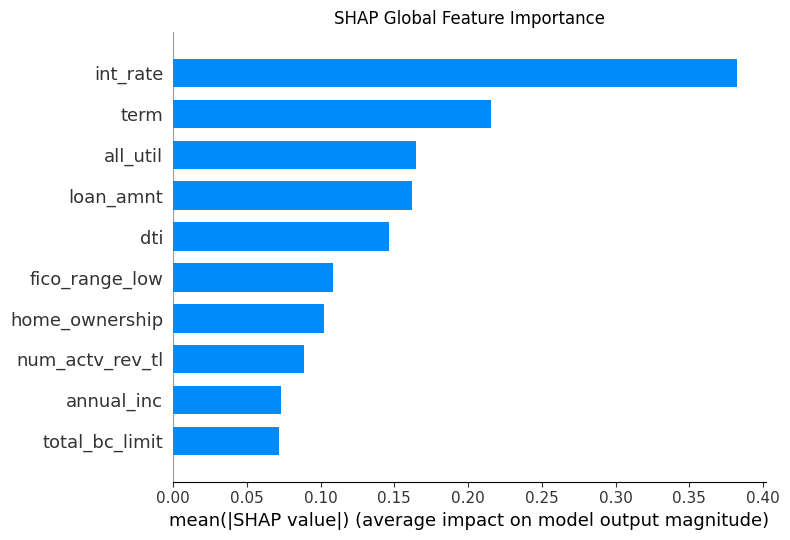

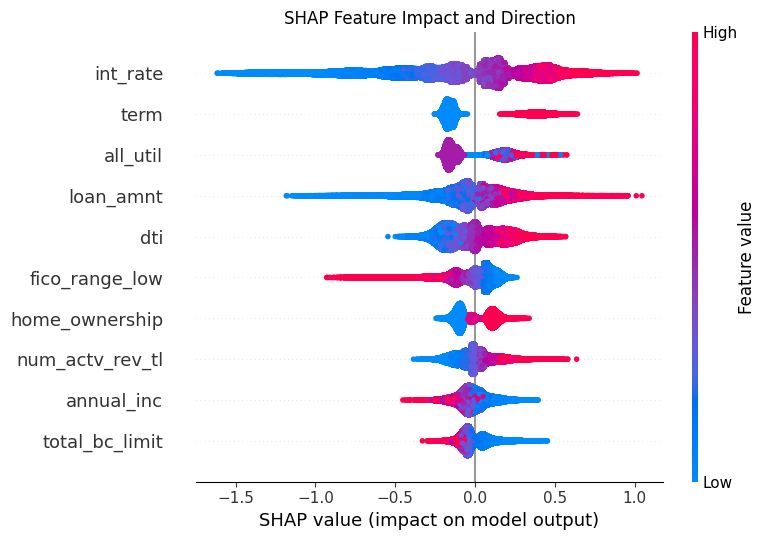

In [ ]:
plot_shap_summary(
    shap_xgb_values, X_test, max_features=10,
    save_prefix=logger.artifact_path("shap_xgb"),
)

### 7.2 SHAP — Random Forest

In [ ]:
shap_rf_df, shap_rf_values = get_shap_importance_rf(rf, X_test)
shap_rf_df.to_csv(logger.artifact_path("shap_importance_rf.csv"), index=False)
shap_rf_df.head(20)

,Feature,SHAP_Value_Contribution
0,int_rate,0.109477
1,term,0.050103
2,all_util,0.014404
3,fico_range_low,0.012264
4,mort_acc,0.010898
5,tot_hi_cred_lim,0.008694
6,dti,0.008412
7,home_ownership,0.004926
8,loan_amnt,0.002755
9,emp_length,0.002011


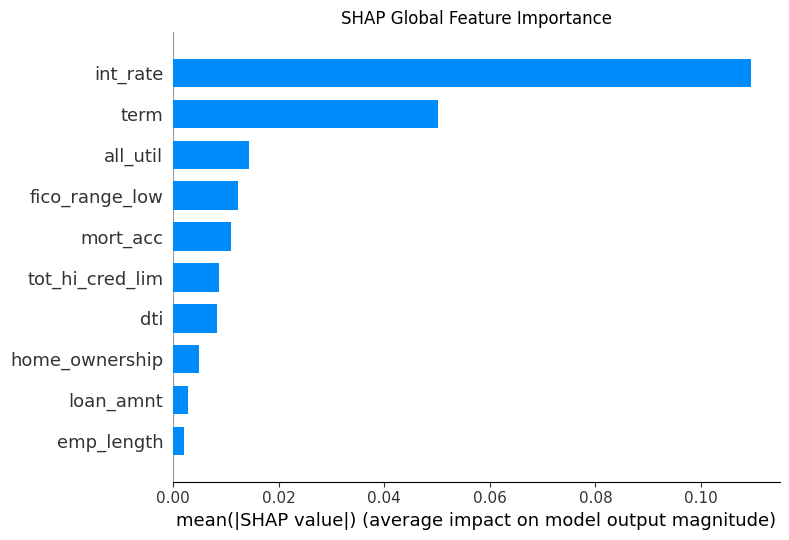

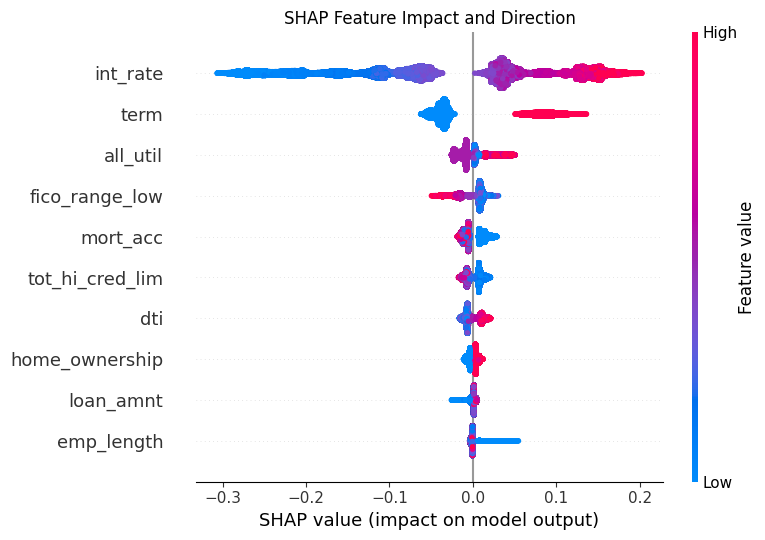

In [ ]:
plot_shap_summary(
    shap_rf_values, X_test, max_features=10,
    save_prefix=logger.artifact_path("shap_rf"),
)

## 8. Summary

`save_run_artifacts` already appended each model's test-set row to
`results/summary_test_metrics_lending_club.csv` as we trained. The cells
below reload that file plus `timings.csv` to give a single view of
everything we just ran.

In [ ]:
summary = load_summary(RESULTS_DIR, "lending_club")
summary[[
    "model_name", "AUC", "Gini", "KS_Statistic", "AUCPR",
    "Precision_top10", "Recall_top10",
]]

,model_name,AUC,Gini,KS_Statistic,AUCPR,Precision_top10,Recall_top10
0,lr_default,0.688899,0.377799,0.276119,0.364269,0.441196,0.208867
1,lr_tuned,0.709734,0.419467,0.305499,0.387741,0.472546,0.223708
2,rf_default,0.712841,0.425682,0.308405,0.394750,0.481775,0.246290
3,rf_tuned,0.704728,0.409456,0.297194,0.382981,0.465737,0.220485
4,xgb_default,0.728454,0.456908,0.334262,0.414850,0.502949,0.238102
5,xgb_tuned,0.732702,0.465403,0.340621,0.423204,0.510741,0.241791


### Timings table (Experiment 2.3 source data)

Wall-clock numbers for every model's default training, tuning loop, tuned
training, and inference latency. Pivoted to one row per model.

In [ ]:
timings = load_timings(ARTIFACTS_DIR)
timings_pivot = (
    timings
    .pivot_table(index="model_name", columns="block", values="seconds", aggfunc="last")
    .round(3)
)
timings_pivot

block,inference_10000,train,tuning_loop
model_name,,,
lr_default,0.002,20.201,NaN
lr_tuned,0.002,27.926,466.808
rf_default,0.439,445.066,NaN
rf_tuned,0.194,1360.406,17643.991
xgb_default,0.011,6.288,NaN
xgb_tuned,0.019,31.082,452.370
